<a href="https://colab.research.google.com/github/1908hanjm/walmart-sales-analysis/blob/main/notebooks/01_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Markdown
# 01. Data Cleaning & Preprocessing (데이터 정제)

### 📌 데이터 정제 및 통합 작업 요약
본 분석을 시작하기 전, 데이터의 무결성을 확보하기 위해 다음 4가지 정제 작업을 수행하였습니다.

1. **날짜 형변환 및 파생변수 생성:** `Date` 컬럼을 `datetime` 형식으로 변환하고, 시계열 분석을 위한 `Year`, `Month`, `Week` 컬럼을 추출함.
2. **결측치(Null) 처리:**
   - `MarkDown1~5`: 프로모션 미실시를 의미하는 `NaN` 값 **1,280,000+ 건을 `0`으로 대체**.
   - `CPI`, `Unemployment`: 직전/직후 값 기반 보간법(`interpolate`)을 적용하여 연속성 유지.
3. **이상치 및 반품 데이터 검증:** `Weekly_Sales`의 **음수 매출 레코드(1,285건)**를 확인하여 고객 반품 및 환불 데이터로 분류.
4. **데이터 병합(Merge):** `train.csv`, `stores.csv`, `features.csv`를 `Store`, `Dept`, `Date` 기

Mounted at /content/drive
=== 정제된 데이터 로드 완료 ===
전체 레코드 수: 421,570 행
분석 기간: 2010-02-05 ~ 2012-10-26



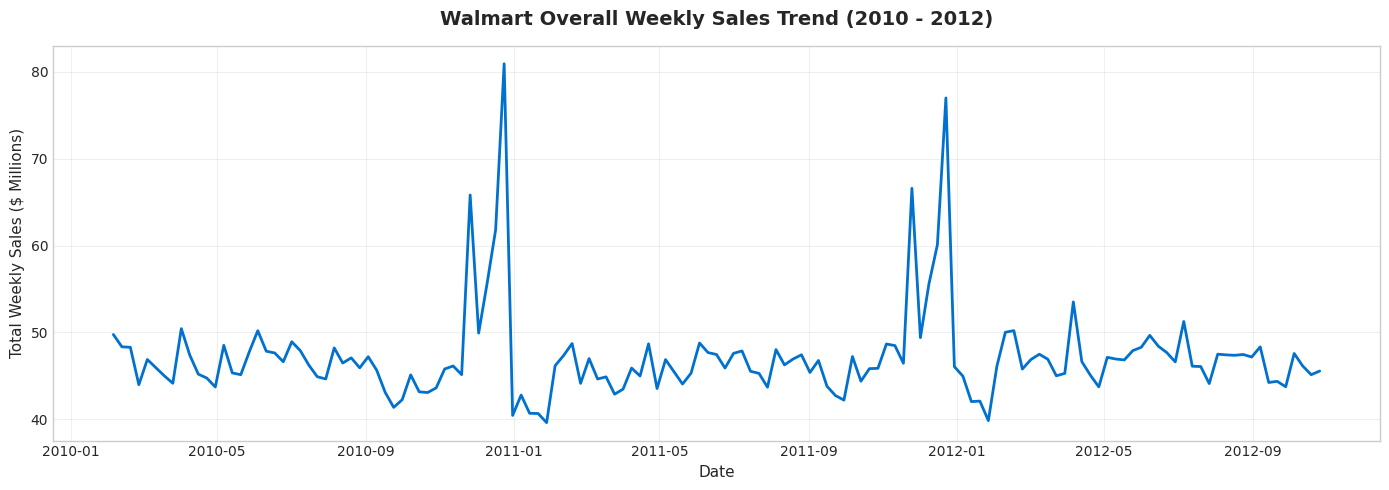

--- Store Type별 요약 ---
  Type  Avg_Weekly_Sales   Total_Sales  Avg_Store_Size  Store_Count
0    A      20099.568043  4.331015e+09   182231.285486           22
1    B      12237.075977  2.000701e+09   101818.735827           17
2    C       9519.532538  4.055035e+08    40535.725286            6


/tmp/ipykernel_1375/1338776622.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_summary, x='Type', y='Avg_Weekly_Sales', palette='Blues_r', ax=axes[0])
/tmp/ipykernel_1375/1338776622.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_summary, x='Type', y='Avg_Store_Size', palette='Greens_r', ax=axes[1])


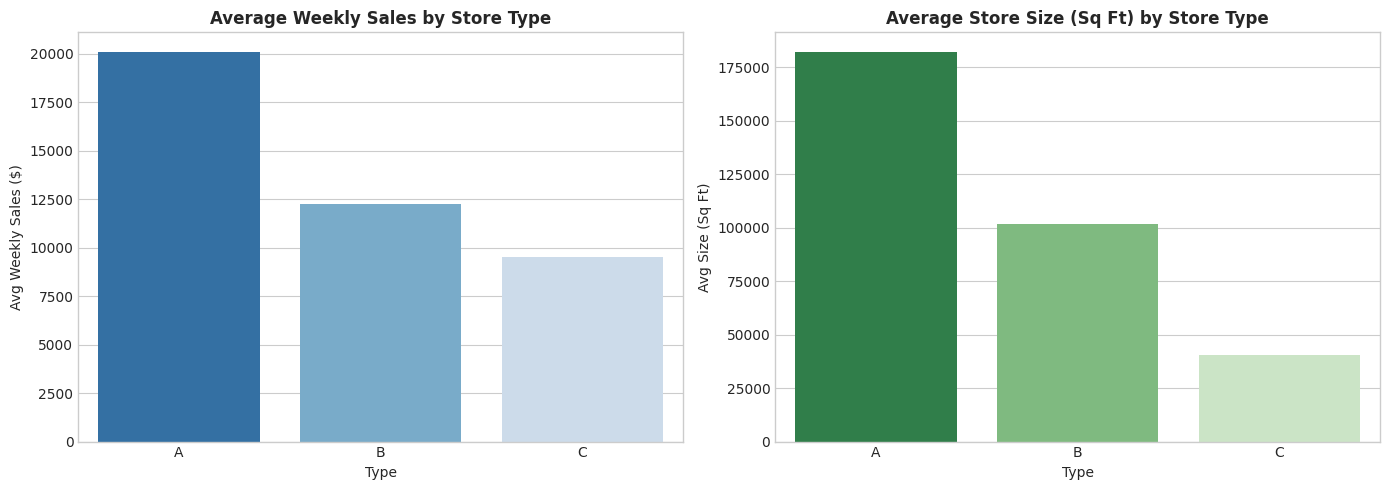


--- Holiday vs Non-Holiday 매출 비교 ---
- 일반 주차 평균 매출 : $15,901.45
- 공휴일 주차 평균 매출: $17,035.82
- 공휴일 매출 증가율   : +7.13%


In [1]:
# ==========================================
# 1. Google Drive 마운트 및 필요 라이브러리 로드
# ==========================================
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 스타일 및 한글/음수 표현 설정
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/포트폴리오-walmart(캐글)/'

# 정제된 데이터 불러오기
df = pd.read_csv(DATA_PATH + 'clean_walmart_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("=== 정제된 데이터 로드 완료 ===")
print(f"전체 레코드 수: {len(df):,} 행")
print(f"분석 기간: {df['Date'].min().strftime('%Y-%m-%d')} ~ {df['Date'].max().strftime('%Y-%m-%d')}\n")

# ==========================================
# 2. Q1. 전체 주간 매출 추세 (Overall Weekly Sales Trend)
# ==========================================
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(weekly_sales['Date'], weekly_sales['Weekly_Sales'] / 1e6, color='#0071CE', linewidth=2)
plt.title('Walmart Overall Weekly Sales Trend (2010 - 2012)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Total Weekly Sales ($ Millions)', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# 3. Q2. Store Type별 평균 매출 & 매장 규모 분석
# ==========================================
type_summary = df.groupby('Type').agg(
    Avg_Weekly_Sales=('Weekly_Sales', 'mean'),
    Total_Sales=('Weekly_Sales', 'sum'),
    Avg_Store_Size=('Size', 'mean'),
    Store_Count=('Store', 'nunique')
).reset_index()

print("--- Store Type별 요약 ---")
print(type_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Type별 평균 매출
sns.barplot(data=type_summary, x='Type', y='Avg_Weekly_Sales', palette='Blues_r', ax=axes[0])
axes[0].set_title('Average Weekly Sales by Store Type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Avg Weekly Sales ($)', fontsize=10)

# Type별 매장 평균 크기
sns.barplot(data=type_summary, x='Type', y='Avg_Store_Size', palette='Greens_r', ax=axes[1])
axes[1].set_title('Average Store Size (Sq Ft) by Store Type', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Avg Size (Sq Ft)', fontsize=10)

plt.tight_layout()
plt.show()

# ==========================================
# 4. Q4. 공휴일(IsHoliday) vs 일반 주차 매출 비교
# ==========================================
holiday_summary = df.groupby('IsHoliday')['Weekly_Sales'].agg(['mean', 'median', 'count']).reset_index()
holiday_summary.columns = ['IsHoliday', 'Mean_Sales', 'Median_Sales', 'Record_Count']

sales_non_holiday = holiday_summary.loc[holiday_summary['IsHoliday'] == False, 'Mean_Sales'].values[0]
sales_holiday = holiday_summary.loc[holiday_summary['IsHoliday'] == True, 'Mean_Sales'].values[0]
pct_diff = ((sales_holiday - sales_non_holiday) / sales_non_holiday) * 100

print("\n--- Holiday vs Non-Holiday 매출 비교 ---")
print(f"- 일반 주차 평균 매출 : ${sales_non_holiday:,.2f}")
print(f"- 공휴일 주차 평균 매출: ${sales_holiday:,.2f}")
print(f"- 공휴일 매출 증가율   : +{pct_diff:.2f}%")

# Q1. 전체 주간 매출 추세 분석
2010년부터 2012년까지 전체 주간 매출 합계 변화를 시계열 그래프로 확인합니다.

특정 시점(11월~12월 연말 시즌)의 매출 급증 패턴을 관찰합니다.

In [2]:
# 1. Google Drive 마운트 및 필요 라이브러리 로드
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/포트폴리오-walmart(캐글)/'

df = pd.read_csv(DATA_PATH + 'clean_walmart_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Q1. 전체 주간 매출 추세 분석
2010년부터 2012년까지 전체 주간 매출 합계 변화를 시계열 그래프로 확인합니다.

특정 시점(11월~12월 연말 시즌)의 매출 급증 패턴을 관찰합니다.